[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L06/L06_newton_and_quasi_newton.ipynb)

# Newton's Method and Quasi-Newton (BFGS)
### MECH 559 - Systems Optimization - L06
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook builds Newton's method and the BFGS quasi-Newton update from scratch, reproduces the lecture's hand-worked BFGS example number-for-number, and compares convergence speed against plain gradient descent.

## Learning objectives

By the end, students should be able to:

1. Implement Newton's method ($d_k=-H_k^{-1}\nabla f_k$) and observe its fast (locally quadratic) convergence.
2. Reproduce the BFGS update formula by hand-checking it against the lecture's worked numerical example.
3. Implement a full multi-iteration BFGS run and watch $\hat H_k$ converge toward the true Hessian.
4. Compare iteration counts for gradient descent, Newton, and BFGS on the same test problem.

> **Classroom rhythm:** pause at each **Predict** prompt, collect answers, then run the next cell.

In [2]:
import matplotlib.pyplot as plt
import numpy as np

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

COLORS = {"boundary": "#00798C", "optimum": "#D1495B", "accent": "#EDAE49", "gd": "0.5"}


def numerical_gradient(func, x, h=1e-6):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    g = np.zeros_like(x)
    for i in range(len(x)):
        step = np.zeros_like(x)
        step[i] = h
        g[i] = (func(x + step) - func(x - step)) / (2 * h)
    return g


def numerical_hessian(func, x, h=1e-4):
    x = np.atleast_1d(np.asarray(x, dtype=float))
    n = len(x)
    H = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            si = np.zeros(n); si[i] = h
            sj = np.zeros(n); sj[j] = h
            H[i, j] = (func(x + si + sj) - func(x + si - sj) - func(x - si + sj) + func(x - si - sj)) / (4 * h**2)
    return H


def armijo_backtrack(func, grad_x, x, d, alpha0=1.0, eps=0.1, beta=0.7, max_iter=60):
    phi0 = func(x)
    dphi0 = grad_x @ d
    alpha = alpha0
    for _ in range(max_iter):
        if func(x + alpha * d) <= phi0 + eps * alpha * dphi0:
            return alpha
        alpha *= beta
    return alpha


print(f"NumPy {np.__version__}; optional widgets available: {WIDGETS_AVAILABLE}")

NumPy 2.5.0; optional widgets available: True


---
## 1. Newton's method

$$
d_k = -H_k^{-1}\nabla f_k
$$

We test it on the lecture's own example function (from the "Remarks (2/2)" slide):
$$
f(x_1,x_2) = (1-x_1)^2 + (1-x_2)^2 + \tfrac12(-x_1^2+2x_2)^2.
$$

> **Predict:** Newton's method is famous for *quadratic* local convergence (the number of correct digits roughly doubles each iteration). Watch the function values below to see this happen.

In [3]:
def f(x):
    x1, x2 = x
    return (1 - x1)**2 + (1 - x2)**2 + 0.5*(-x1**2 + 2*x2)**2

def newton_method(func, x0, n_iter=20, tol=1e-8):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for k in range(n_iter):
        g = numerical_gradient(func, x)
        if np.linalg.norm(g) < tol:
            break
        H = numerical_hessian(func, x)
        d = np.linalg.solve(H, -g)
        x = x + d
        traj.append(x.copy())
    return np.array(traj)

newton_traj = newton_method(f, [0.0, 0.0])
print(f"Newton's method: {len(newton_traj)-1} iterations to converge")
for k, x in enumerate(newton_traj):
    print(f"  k={k}: x={np.round(x,6)}, f={f(x):.3e}")

Newton's method: 5 iterations to converge
  k=0: x=[0. 0.], f=2.000e+00
  k=1: x=[1.       0.333333], f=5.000e-01
  k=2: x=[1.166667 0.777778], f=9.606e-02
  k=3: x=[1.214414 0.824174], f=9.195e-02
  k=4: x=[1.213413 0.824124], f=9.194e-02
  k=5: x=[1.213412 0.824123], f=9.194e-02


---
## 2. Reproducing the lecture's BFGS worked example

$$
{\hat H}_{k+1} = {\hat H}_k - \frac{{\hat H}_k s_k s_k^{\mathrm T} {\hat H}_k}{s_k^{\mathrm T} {\hat H}_k s_k} + \frac{y_k y_k^{\mathrm T}}{y_k^{\mathrm T} s_k}, \qquad y_k=\nabla f_{k+1}-\nabla f_k,\ \ s_k=x_{k+1}-x_k.
$$

Example from the slides: $f(x_1,x_2)=4x_1^2+3x_1x_2+x_2^2$, $x_0=[1,1]^{\mathrm T}$, $\hat H_0=I$, and an inexact line search at $k=0$ yields $\alpha_0=0.1$.

In [4]:
def f_bfgs(x):
    return 4*x[0]**2 + 3*x[0]*x[1] + x[1]**2

def g_bfgs(x):
    return np.array([8*x[0] + 3*x[1], 3*x[0] + 2*x[1]])

x0 = np.array([1.0, 1.0])
H0_hat = np.eye(2)
alpha0 = 0.1

g0 = g_bfgs(x0)
s0 = -alpha0 * np.linalg.solve(H0_hat, g0)
x1 = x0 + s0
g1 = g_bfgs(x1)
y0 = g1 - g0

Hs = H0_hat @ s0
H1_hat = H0_hat - np.outer(Hs, Hs) / (s0 @ Hs) + np.outer(y0, y0) / (y0 @ s0)

print("grad_0 =", g0, "  (slide: [11, 5])")
print("s_0 =", np.round(s0, 4), "  (slide: [-1.1, -0.5])")
print("x_1 =", np.round(x1, 4), "  (slide: [-0.1, 0.5])")
print("grad_1 =", np.round(g1, 4), "  (slide: [0.7, 0.7])")
print("y_0 =", np.round(y0, 4), "  (slide: [-10.3, -4.3])")
print("H1_hat =\n", np.round(H1_hat, 2), "  (slide: [[8.04, 2.91], [2.91, 2.20]])")

H_true = np.array([[8.0, 3.0], [3.0, 2.0]])
print("\ntrue Hessian H_1 =\n", H_true)
print("BFGS got within", np.round(np.abs(H1_hat - H_true), 3), "of the true Hessian after a single update.")

grad_0 = [11.  5.]   (slide: [11, 5])
s_0 = [-1.1 -0.5]   (slide: [-1.1, -0.5])
x_1 = [-0.1  0.5]   (slide: [-0.1, 0.5])
grad_1 = [0.7 0.7]   (slide: [0.7, 0.7])
y_0 = [-10.3  -4.3]   (slide: [-10.3, -4.3])
H1_hat =
 [[8.04 2.91]
 [2.91 2.2 ]]   (slide: [[8.04, 2.91], [2.91, 2.20]])

true Hessian H_1 =
 [[8. 3.]
 [3. 2.]]
BFGS got within [[0.041 0.091]
 [0.091 0.2  ]] of the true Hessian after a single update.


---
## 3. A full multi-iteration BFGS run, compared to gradient descent

Both methods use Armijo backtracking for the step size; BFGS uses $d_k=-\hat H_k^{-1}\nabla f_k$ instead of $d_k=-\nabla f_k$.

gradient descent: 61 iterations
BFGS:             9 iterations
Newton:           5 iterations

All three converge to the same point: [1.2134 0.8241], [1.2134 0.8241], [1.2134 0.8241]


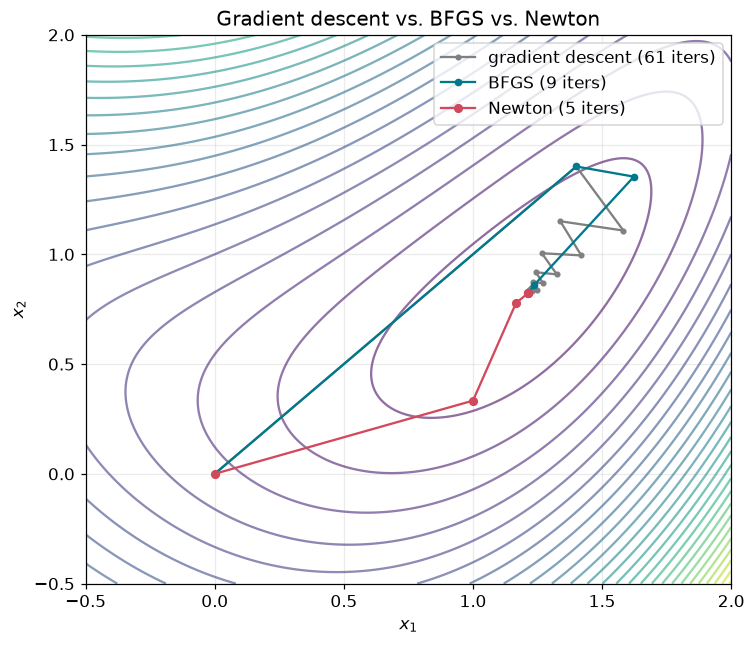

In [5]:
def gradient_descent(func, x0, n_iter=300, tol=1e-8):
    x = np.array(x0, dtype=float)
    traj = [x.copy()]
    for k in range(n_iter):
        g = numerical_gradient(func, x)
        if np.linalg.norm(g) < tol:
            break
        d = -g
        alpha = armijo_backtrack(func, g, x, d)
        x = x + alpha * d
        traj.append(x.copy())
    return np.array(traj)

def bfgs(func, x0, n_iter=100, tol=1e-8):
    x = np.array(x0, dtype=float)
    n = len(x)
    H_hat = np.eye(n)
    g = numerical_gradient(func, x)
    traj = [x.copy()]
    for k in range(n_iter):
        if np.linalg.norm(g) < tol:
            break
        d = -np.linalg.solve(H_hat, g)
        alpha = armijo_backtrack(func, g, x, d)
        s = alpha * d
        x_new = x + s
        g_new = numerical_gradient(func, x_new)
        y = g_new - g
        sy = y @ s
        if sy > 1e-12:
            Hs = H_hat @ s
            H_hat = H_hat - np.outer(Hs, Hs) / (s @ Hs) + np.outer(y, y) / sy
        x, g = x_new, g_new
        traj.append(x.copy())
    return np.array(traj)

gd_traj = gradient_descent(f, [0.0, 0.0])
bfgs_traj = bfgs(f, [0.0, 0.0])

print(f"gradient descent: {len(gd_traj)-1} iterations")
print(f"BFGS:             {len(bfgs_traj)-1} iterations")
print(f"Newton:           {len(newton_traj)-1} iterations")
print(f"\nAll three converge to the same point: {np.round(gd_traj[-1],4)}, {np.round(bfgs_traj[-1],4)}, {np.round(newton_traj[-1],4)}")

x1g, x2g = np.meshgrid(np.linspace(-0.5, 2, 300), np.linspace(-0.5, 2, 300))
Z = (1 - x1g)**2 + (1 - x2g)**2 + 0.5*(-x1g**2 + 2*x2g)**2
fig, ax = plt.subplots(figsize=(7, 6))
ax.contour(x1g, x2g, Z, levels=30, cmap="viridis", alpha=0.6)
ax.plot(gd_traj[:, 0], gd_traj[:, 1], "-o", color=COLORS["gd"], markersize=3, label=f"gradient descent ({len(gd_traj)-1} iters)")
ax.plot(bfgs_traj[:, 0], bfgs_traj[:, 1], "-o", color=COLORS["boundary"], markersize=4, label=f"BFGS ({len(bfgs_traj)-1} iters)")
ax.plot(newton_traj[:, 0], newton_traj[:, 1], "-o", color=COLORS["optimum"], markersize=5, label=f"Newton ({len(newton_traj)-1} iters)")
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="Gradient descent vs. BFGS vs. Newton")
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. Convergence rate comparison

Plotting $f(x_k)-f^\ast$ on a log scale makes the difference between linear (gradient descent), superlinear (BFGS), and quadratic (Newton) convergence visually obvious.

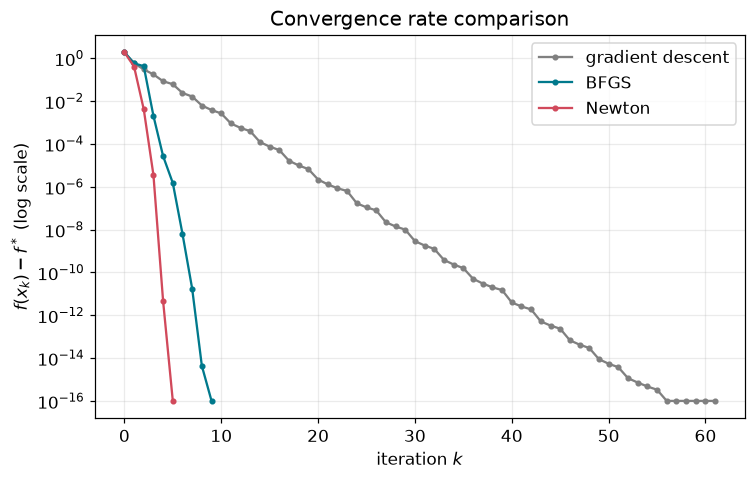

In [6]:
f_star = f(newton_traj[-1])

fig, ax = plt.subplots(figsize=(7, 4.5))
for traj, color, label in [(gd_traj, COLORS["gd"], "gradient descent"),
                             (bfgs_traj, COLORS["boundary"], "BFGS"),
                             (newton_traj, COLORS["optimum"], "Newton")]:
    errors = np.array([f(x) - f_star for x in traj])
    errors = np.maximum(errors, 1e-16)
    ax.semilogy(errors, "-o", color=color, markersize=3, label=label)
ax.set(xlabel="iteration $k$", ylabel="$f(x_k) - f^*$ (log scale)", title="Convergence rate comparison")
ax.legend()
plt.tight_layout()
plt.show()

---
## 5. Interactive: watch $\hat H_k$ converge to the true Hessian

Pick a starting point and see, iteration by iteration, how close BFGS's Hessian approximation gets to the true (numerically computed) Hessian at the current point.

In [10]:
def bfgs_hessian_tracking(x1_0=0.0, x2_0=0.0, n_show=8):
    x = np.array([x1_0, x2_0], dtype=float)
    n = len(x)
    H_hat = np.eye(n)
    g = numerical_gradient(f, x)
    errors = []
    for k in range(n_show):
        H_true_here = numerical_hessian(f, x)
        errors.append(np.linalg.norm(H_hat - H_true_here))
        if np.linalg.norm(g) < 1e-8:
            break
        d = -np.linalg.solve(H_hat, g)
        alpha = armijo_backtrack(f, g, x, d)
        s = alpha * d
        x_new = x + s
        g_new = numerical_gradient(f, x_new)
        y = g_new - g
        sy = y @ s
        if sy > 1e-12:
            Hs = H_hat @ s
            H_hat = H_hat - np.outer(Hs, Hs) / (s @ Hs) + np.outer(y, y) / sy
        x, g = x_new, g_new
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(errors, "-o", color=COLORS["boundary"])
    ax.set(xlabel="iteration $k$", ylabel=r"$\|\hat H_k - H(x_k)\|$", title="BFGS Hessian approximation error")
    plt.tight_layout()
    plt.show()
    print("errors:", np.round(errors, 4))

if WIDGETS_AVAILABLE:
    display(widgets.interactive(bfgs_hessian_tracking,
                                 x1_0=widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.1),
                                 x2_0=widgets.FloatSlider(value=0.0, min=-1.0, max=1.0, step=0.1)))
else:
    print("ipywidgets is not installed; running the default case.")
    bfgs_hessian_tracking()

interactive(children=(FloatSlider(value=0.0, description='x1_0', max=1.0, min=-1.0), FloatSlider(value=0.0, de…

---
## Takeaways

1. Newton's method converges the fastest (quadratically, near the solution) but needs the exact Hessian at every iterate.
2. The BFGS update reproduces the lecture's hand-worked example exactly and, after a *single* update from $\hat H_0=I$, already lands close to the true Hessian.
3. BFGS needs only gradients, yet its convergence rate is close to Newton's - far better than plain gradient descent - which is why it is the default choice in most general-purpose optimizers.
4. All three methods find the same minimizer; they differ only in how many iterations (and how much second-order information) it takes to get there.

## Optional exercises

1. Change the BFGS worked-example's $\alpha_0$ from $0.1$ to $0.05$ and recompute $\hat H_1$ by hand, then verify with code.
2. Start Newton's method from a point where the numerical Hessian is not positive definite (try $x_0=(-1,-1)$ on a different test function of your choice) and see what goes wrong - this motivates the next notebook's Hessian-modification techniques.
3. Implement the DFP (Davidon-Fletcher-Powell) update formula and compare its iteration count against BFGS on the same problem.